C:\Users\nopan\miniconda3\envs\ms_co2_penalty\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading BE-Maa ...
Loaded .parquet file L:\Sync\luhk_work\40 - DATA\Datasets\2024 - ICOS - Ecosystem final quality (L2) product in ETC-Archive format - release 2024-1\2-FLUXNET_HH_PARQUET\ICOSETC_BE-Maa_FLUXNET_HH_L2.csv.parquet (0.082 seconds). Detected time resolution of <30 * Minutes> / 30min 


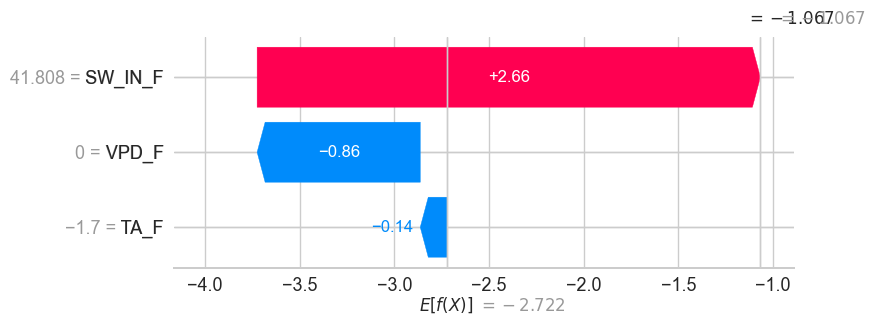

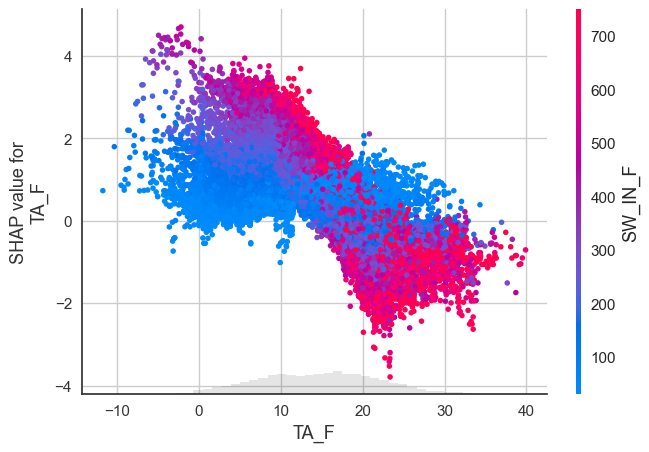

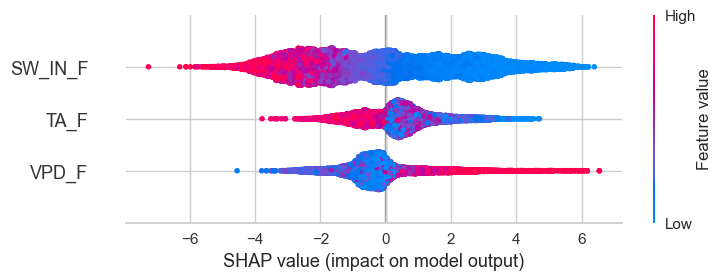

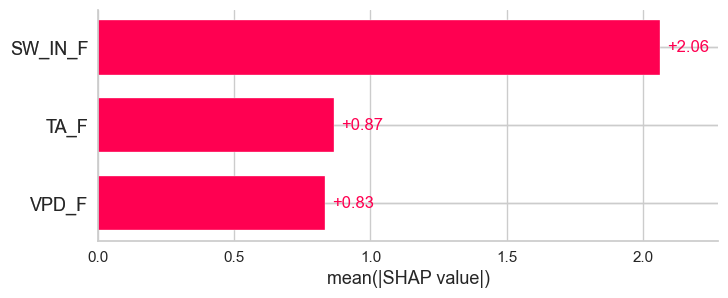

In [1]:
"""

Example:
https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Front%20page%20example%20%28XGBoost%29.html

"""

from pathlib import Path
import shap
import xgboost
import matplotlib.pyplot as plt
import pandas as pd
from diive.core.io.filereader import search_files
from diive.core.io.files import load_parquet

pd.set_option('display.max_rows', 3000)
pd.set_option('display.max_columns', 3000)

SEARCHDIRS = r"L:\Sync\luhk_work\40 - DATA\Datasets\2024 - ICOS - Ecosystem final quality (L2) product in ETC-Archive format - release 2024-1\2-FLUXNET_HH_PARQUET"
IDENTIFIERS = ['ICOSETC_', '_FLUXNET_HH_L2', '.csv.parquet']

filepaths = search_files(searchdirs=SEARCHDIRS, pattern=r"ICOSETC_*_FLUXNET_HH_L2.csv.parquet")

sites_df = pd.DataFrame()
for ix, filepath in enumerate(filepaths):
    if ix == 3:
        _filename = Path(filepath).name
        splits = _filename.split('_')
        site = splits[1]
        print(f"Reading {site} ...")
        df = load_parquet(filepath=filepath)
        df = df.loc[df['SW_IN_F'] > 20, :]
        # [print(c) for c in df.columns if "P_F" in c];
        break


X = df[['TA_F', 'VPD_F', 'SW_IN_F']].copy()
y = df[['NEE_VUT_50']].copy()
# train an XGBoost model

# train an XGBoost model
model = xgboost.XGBRegressor().fit(X, y)
# model = CatBoostRegressor(iterations=300, learning_rate=0.1, random_seed=123)

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
_shap_values = shap_values.values


# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

shap.plots.initjs()


# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0])

# visualize all the training set predictions
shap.plots.force(shap_values[:500])

# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "TA_F"], color=shap_values)

# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

shap.plots.bar(shap_values)



